In [3]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [59]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.1 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 26.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------ --------------------------------- 6.0/37.3 MB 30.0 MB/s eta 0:00:02
   ------------- -------------------------- 12.8/37.3 MB 31.2 MB/s eta 0:00:01
   ----------------- ---------------------- 16.0/37.3 MB 25.5 MB/s eta 0:00:01
   ----------------------- ---------------- 21.5/37.3 MB 25.6 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/37.3 MB 25.8 MB/s eta 0:00:01
   ----------------------------------- ---- 33.3/37.3 MB 26.4 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 25.5 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [7]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
df.shape
df.columns
df.info()
df["Attrition"].value_counts()
df["Attrition"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [12]:
df["Over18"].value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [13]:
df["StandardHours"].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

In [14]:
df = df.drop(columns=["StandardHours", "Over18"])

In [15]:
df["EmployeeCount"].value_counts()

EmployeeCount
1    1470
Name: count, dtype: int64

In [16]:
df = df.drop(columns=["EmployeeCount"])

In [17]:
df = df.drop(columns=["EmployeeNumber"])

In [18]:
df.shape

(1470, 31)

In [19]:
df.shape
df.columns
df.info()
df["Attrition"].value_counts()
df["Attrition"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [25]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='str')

Numerical columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


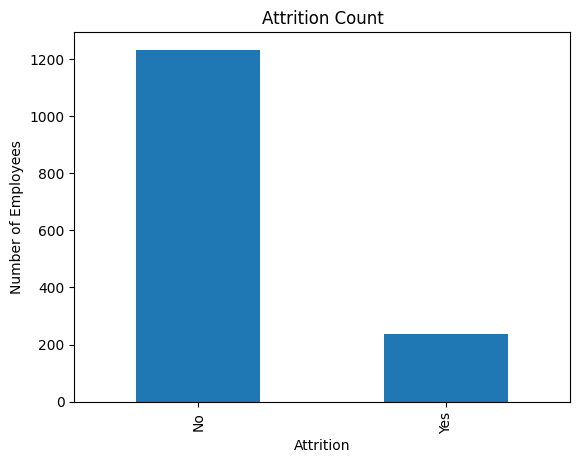

In [26]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")
plt.title("Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [27]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Attrition Overview: 
Approximately 16.1% of employees have left the company. Attrition is present but not dominate for this dataset.

In [28]:
pd.crosstab(df["Department"], df["Attrition"], normalize="index") * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


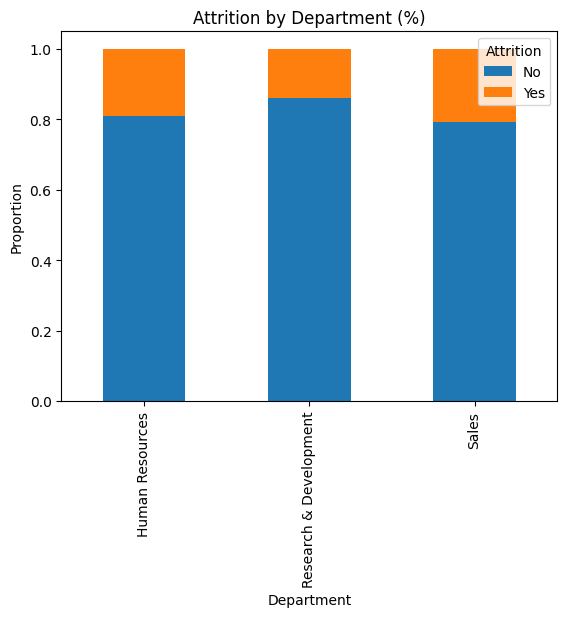

In [35]:
pd.crosstab(df["Department"], df["Attrition"], normalize="index").plot(kind="bar", stacked=True)

plt.title("Attrition by Department (%)")
plt.ylabel("Proportion")
plt.show()

In [30]:
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Attrition by Department:
Sales and Human Resources exhibit higher proportions of attrition compared to Research and Development, which shows a notably lower attrition rate. This suggests that department-level differences may be associated with employee turnover. However, additional analysis is required to determine which specific factors (e.g., compensation, workload, or job satisfaction) are driving these differences.

In [36]:
pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100

plt.title("Attrition by Overtime (%)")
plt.ylabel("Proportion")
plt.show()

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


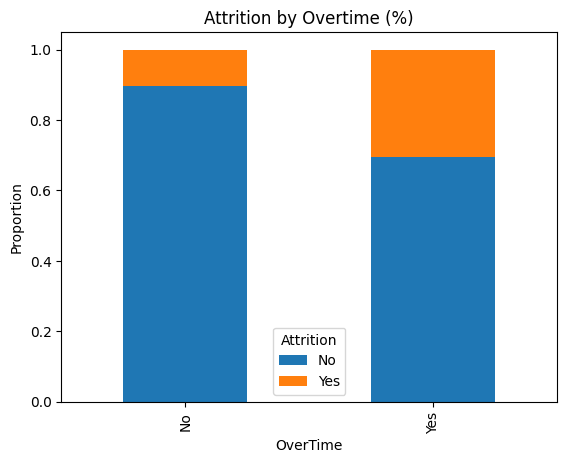

In [37]:
pd.crosstab(df["OverTime"], df["Attrition"], normalize="index").plot(kind="bar", stacked=True)

plt.title("Attrition by Overtime (%)")
plt.ylabel("Proportion")
plt.show()

Attrition by Overtime:
Employees who work overtime exhibit a substantially higher proportion of attrition compared to those who do not. This suggests that overtime may be associated with increased employee turnover. Further analysis is needed to determine whether workload, job stress, or other factors contribute to this relationship.

In [38]:
df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

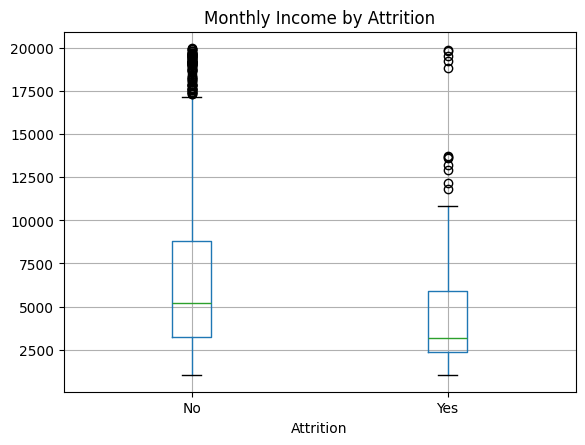

In [42]:
df.boxplot(column="MonthlyIncome", by="Attrition")
plt.title("Monthly Income by Attrition")
plt.suptitle("")
plt.show()

Attrition by Monthly Income:
Employees who left the company tend to have lower monthly incomes compared to those who remained. This suggests that compensation may be associated with employee attrition, although further analysis is needed to determine the strength and cause of this relationship.

In [47]:
df.groupby(["OverTime", "Attrition"])["MonthlyIncome"].mean()

OverTime  Attrition
No        No           6669.690678
          Yes          4899.318182
Yes       No           7365.328720
          Yes          4689.889764
Name: MonthlyIncome, dtype: float64

In [45]:
df.groupby(["OverTime", "Attrition"])["MonthlyIncome"].mean().unstack()

Attrition,No,Yes
OverTime,,
No,6669.690678,4899.318182
Yes,7365.328720,4689.889764


Combined Effect of Overtime and Income:
Across both overtime groups, employees who left the company have lower average monthly incomes than those who remained. The lowest income is observed among employees who both worked overtime and left the company, suggesting that the combination of lower compensation and overtime may be associated with higher attrition. This indicates that multiple factors may interact to influence employee turnover.

In [48]:
df.groupby("Attrition")["YearsAtCompany"].mean()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

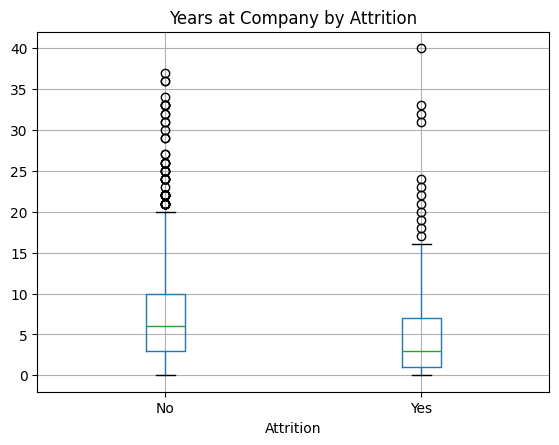

In [49]:
df.boxplot(column="YearsAtCompany", by="Attrition")
plt.title("Years at Company by Attrition")
plt.suptitle("")
plt.show()

Attrition by Tenure:
Employees who left the company tend to have fewer years at the company compared to those who remained. This suggests that lower tenure may be associated with higher attrition, indicating that newer employees are more likely to leave.

In [50]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [51]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [52]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [53]:
df_encoded.shape

(1470, 45)

In [56]:
df_encoded.shape
df_encoded.columns
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked             

In [57]:
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train.shape, X_test.shape

((1176, 44), (294, 44))

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\wwwse\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [67]:
y_pred = model.predict(X_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8775510204081632


In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.55      0.44      0.49        39

    accuracy                           0.88       294
   macro avg       0.73      0.69      0.71       294
weighted avg       0.87      0.88      0.87       294



In [70]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[241  14]
 [ 22  17]]


Model Evaluation:
The model achieved an accuracy of approximately 87.8%. However, performance on employees who left (Attrition = 1) is weaker, with a recall of 44%. This indicates that the model misses a substantial portion of employees who actually leave. While overall accuracy is high, the model is limited in its ability to identify employees at risk of attrition.

In [71]:
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82       255
           1       0.26      0.59      0.36        39

    accuracy                           0.72       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.83      0.72      0.76       294



Handling Class Imbalance:
To improve the model’s ability to detect employees who leave, class weights were adjusted to account for imbalance in the dataset. As a result, recall for employees who left increased from 44% to 59%, indicating that the model is better at identifying at-risk employees.

However, this improvement comes at a cost. Overall accuracy decreased from approximately 87.8% to 72%, and precision for predicting attrition dropped significantly. This indicates that while the model now detects more true leavers, it also produces more false positives. 

This highlights an important trade-off between accurately identifying employees at risk of leaving and maintaining overall prediction accuracy.